# NorESM Station Susceptibility — Aitken vs Accumulation Mode

**Question:** Does the CCN→CDNC susceptibility (d ln CDNC / d ln CCN) differ between
columns dominated by *Aitken-mode* aerosol versus *accumulation-mode* aerosol?

Approach: at each station/time/level we (1) compute an Aitken-to-accumulation number
ratio from the NorESM size distribution, (2) split into the high-Aitken (top quartile)
and high-accumulation (bottom quartile) populations, then (3) regress log CDNC on
log CCN within each population, stratified by sub-grid updraft.

*(noCHC sensitivity analysis removed — Chacaltaya is no longer excluded.)*

## 1. Setup and data load

In [1]:
# Shared lab module (susceptibility builders, NorESM extractors, ERF integrator)
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import statsmodels.api as sm
from scipy.odr import ODR, Model, RealData
from matplotlib.colors import LogNorm
from sklearn.cluster import KMeans
from scipy import optimize
import pylab as pl

In [2]:
# --- Paths and analysis grid ---
NorPath = "/share/sabl0586/all_stations_NorESM_OsloAero_prcp2szdst_f19_f19_noresmv211_corr_ilevall_levs_4Peter.nc"
ds = xr.open_dataset(NorPath, chunks={})
stations = ds["station"].values
radii = np.logspace(0, 2.7, 61)   # 1 -> ~500 nm RADIUS, log-spaced (diameter = 2*radius)
VarList = ['FREQL', 'Z3', 'WSUB']
x = xr.DataArray(np.logspace(-0.5, 6, num=200), dims=['D'], coords={'D': np.logspace(-0.5, 6, num=200)})  # diameter grid for PNSD integration


## 2. Build the per-station CCN / CDNC dataset

In [3]:
def CCN_CDNC_Dataset(CCN_ds, CDNC_da):
    """
    Compute OLS slope/intercept between CCN(radius, lev, time)
    and CDNC(lev, time) across 'time'.
    """
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)

   
    
    ds_out = xr.Dataset(
        data_vars={
            'CCN': CCN_aligned,       # dims: (radius, lev, time)
            'CDNC': CDNC_aligned      # dims: (lev, time)
        },
        coords={
            'radius': CCN_aligned.radius,
            'lev': CCN_aligned.lev,
            'time': CCN_aligned.time
        }
    )

    return ds_out

In [4]:
# Loop stations: extract NorESM fields, integrate PNSD into CCN(>r), and pair with
# cloud-base CDNC. CDNC is masked to liquid-cloud points (FREQL > 0.8 = >80% cloud cover).
all_stationsCCN = []
all_stationsHeight = []
#CCN_all = xr.open_dataset('/share/pech2273/NorESM_CCN_CDNC.nc')
Downloaded = False
for station in stations:
    if Downloaded is False:

        Nor_ds = Function.NorESMExtract_Dask(NorPath, station, VarList, x, PNSD=False)
        CCN_ds = Function.NorERF(Nor_ds, radii)

        ## Mask CDNC where liquid cloud fraction > 80%
        Levels_CCN_ds = CCN_CDNC_Dataset(CCN_ds, Nor_ds['CDNC'].where(Nor_ds['FREQL']>0.8))
        all_stationsCCN.append(Levels_CCN_ds.assign_coords(station=station))


# Concatenate across stations
if Downloaded is False:
    CCN_all = xr.concat(all_stationsCCN, dim='station')

CCN_all = CCN_all.compute()   # force eval once; downstream masking is heavy


/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


## 3. Aitken / accumulation ratio and its distribution

In [5]:
# === Aitken-to-accumulation ratio (the size-distribution shape metric) ===
# NorERF integrates the lognormal PNSD above a radius cutoff, giving cumulative
# number concentration N(>r). Cutoffs here are 10 nm and 50 nm RADIUS
# (= 20 nm and 100 nm DIAMETER).
AitAcc_ds = Function.NorERF(ds, [10, 50])

N20  = AitAcc_ds.sel(radius=10)   # N(>20 nm diameter): Aitken + accumulation + coarse
N100 = AitAcc_ds.sel(radius=50)   # N(>100 nm diameter): accumulation + coarse only

# NEW NORM for the Ait/Acc ratio: (N20 - N100) / N100
#   numerator  N20 - N100 = number in the 20-100 nm band (~Aitken population)
#   denominator N100       = number above 100 nm          (~accumulation population)
# High ratio -> Aitken-dominated (clean/fresh); low ratio -> accumulation-dominated (aged).
TotalAitAccRatio = (N20 - N100) / N100

# Split the ratio by whether a cloud-base CDNC sample exists at that point.
AitAccRatio2 = TotalAitAccRatio.compute().where(CCN_all.CDNC.isnull(),  drop=True)  # no CDNC
AitAccRatio  = TotalAitAccRatio.compute().where(CCN_all.CDNC.notnull(), drop=True)  # with CDNC


In [6]:
Updraft = ds.WSUB.compute()

Quartiles of the ratio — the Q25 / Q75 cuts used below to define the two populations.

In [7]:
print(f'Aitken to Accumulation Ratio 25th quantile: {TotalAitAccRatio.quantile(0.25).values:.2f}')
print(f'Aitken to Accumulation Ratio 75th quantile: {TotalAitAccRatio.quantile(0.75).values:.2f}')

Aitken to Accumulation Ratio 25th quantile: 1.43
Aitken to Accumulation Ratio 75th quantile: 4.04


In [8]:
print(f'Aitken to Accumulation Ratio (with CDNC) 25th quantile: {AitAccRatio.quantile(0.25).values:.2f}')
print(f'Aitken to Accumulation Ratio (with CDNC) 75th quantile: {AitAccRatio.quantile(0.75).values:.2f}')

Aitken to Accumulation Ratio (with CDNC) 25th quantile: 1.74
Aitken to Accumulation Ratio (with CDNC) 75th quantile: 5.35


In [9]:
print(f'Aitken to Accumulation Ratio (no CDNC) 25th quantile: {AitAccRatio2.quantile(0.25).values:.2f}')
print(f'Aitken to Accumulation Ratio (no CDNC) 75th quantile: {AitAccRatio2.quantile(0.75).values:.2f}')

Aitken to Accumulation Ratio (no CDNC) 25th quantile: 1.42
Aitken to Accumulation Ratio (no CDNC) 75th quantile: 3.99


Distribution of the ratio (per station, and pooled with/without CDNC).

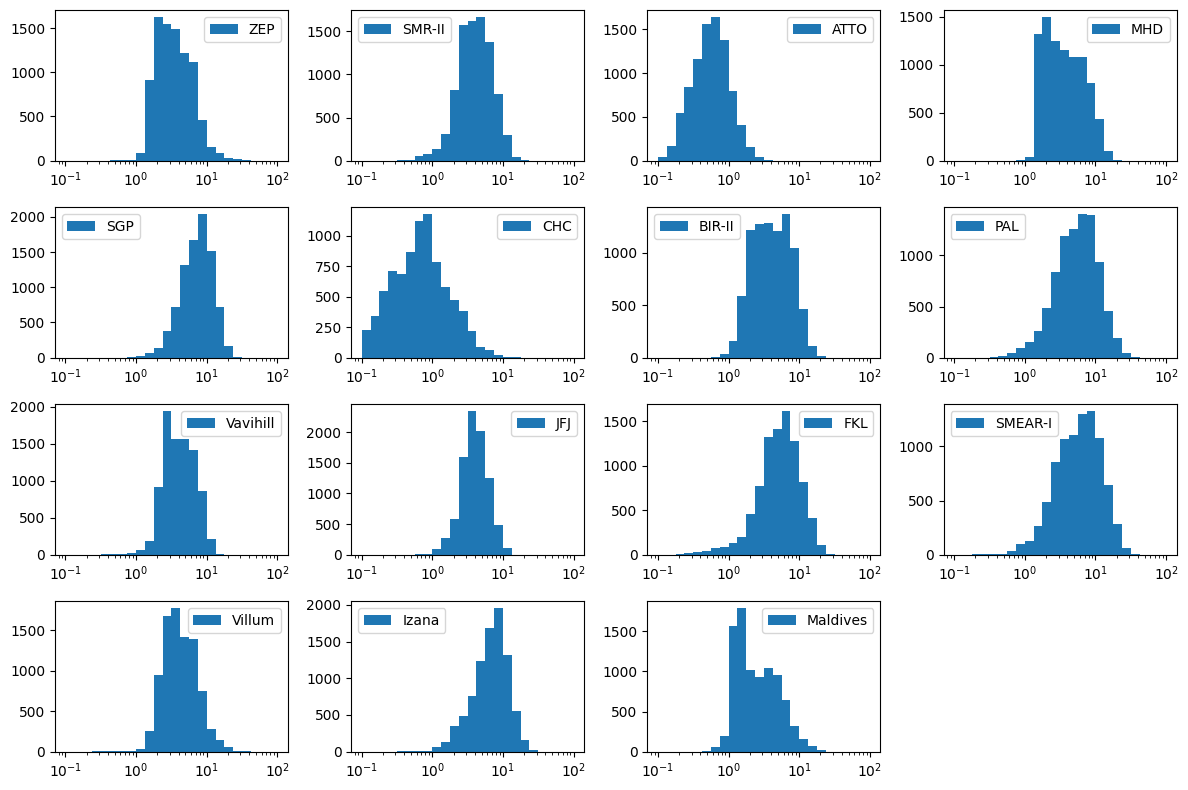

In [10]:
bins = np.logspace(-1,2, 25)
plt.figure(figsize= [12,8])
for x, station in enumerate(ds.station.values):
    plt.subplot(4,4,x+1)
    plt.hist(TotalAitAccRatio.sel(station = station).isel(lev = -1), bins = bins, label = station)
    plt.xscale('log')
    plt.legend()
plt.tight_layout()

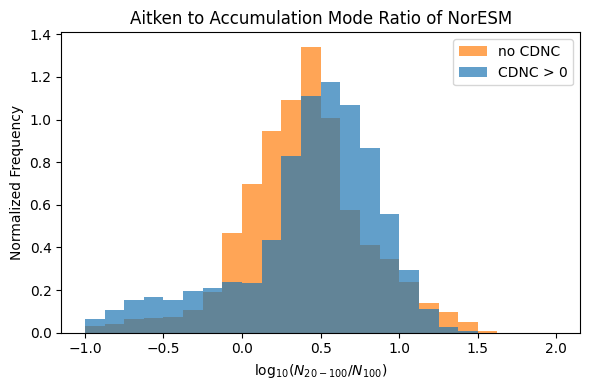

In [11]:
bins = np.linspace(-1, 2, 25)
plt.figure(figsize=[6, 4])
plt.hist(
    [np.log10(AitAccRatio.values.flatten()),np.log10(AitAccRatio2.values.flatten())], 
    density = True,
    bins = bins,
    stacked = False,
    histtype = 'stepfilled',
    alpha = 0.7,
    label=['CDNC > 0', 'no CDNC']
)
plt.ylabel('Normalized Frequency')
plt.xlabel('log$_{10}$($N_{20-100}/N_{100}$)')
plt.title('Aitken to Accumulation Mode Ratio of NorESM')
plt.legend()
plt.tight_layout()

## 4. Define the high-Aitken and high-accumulation populations

Lower quartile of the ratio = accumulation-dominated (`BigAcc`); upper quartile =
Aitken-dominated (`BigAit`). Cells below are two binning conventions (global vs
per-station quartile) — the per-station one is carried forward.

In [12]:
# --- Global-quartile split (kept for reference; superseded by per-station below) ---
mask = (AitAccRatio <= AitAccRatio.quantile(0.25)).compute().reset_coords("radius", drop=True)
BigAcc = CCN_all.where(mask, drop=True)

mask = (AitAccRatio >= AitAccRatio.quantile(0.75)).compute().reset_coords("radius", drop=True)
BigAit = CCN_all.where(mask, drop=True)


In [13]:
# --- Per-station quartile split (THIS is the version used downstream) ---
# Collapse every dim except 'station' so quartiles are computed per station,
# avoiding a few polluted stations dominating the global cut.
dims = [d for d in AitAccRatio.dims if d != "station"]

# lower quartile per station -> high accumulation mode
q25 = AitAccRatio.quantile(0.25, dim=dims)
mask_low = (AitAccRatio <= q25)
BigAcc = CCN_all.where(mask_low)

# upper quartile per station -> high Aitken mode
q75 = AitAccRatio.quantile(0.75, dim=dims)
mask_high = (AitAccRatio >= q75)
BigAit = CCN_all.where(mask_high)


In [14]:
BigAcc = BigAcc.where(BigAcc.CDNC.notnull(), drop = True)
BigAit = BigAit.where(BigAit.CDNC.notnull(), drop = True)

## 5. Stack into (CCN, CDNC, updraft) sample pairs

Broadcast against `WSUB` and flatten station/time/lev into a single `sample`
dimension. CDNC/Updraft don't vary with the CCN cutoff radius, so that axis is dropped.
These `Pairs_*` datasets are the regression inputs.

In [15]:
CDNC_b, CCN_b, WSUB_b = xr.broadcast(BigAcc.CDNC, BigAcc.CCN, ds.WSUB)
Pairs_acc = xr.Dataset({
    "CDNC": CDNC_b,
    "CCN": CCN_b,
    "Updraft": WSUB_b
}).stack(sample=("station", "time", "lev"))
Pairs_acc = Pairs_acc.where(Pairs_acc.CDNC.notnull(), drop=True)
Pairs_acc['CDNC'] = Pairs_acc['CDNC'].isel(radius = 0)
Pairs_acc['Updraft'] = Pairs_acc['Updraft'].isel(radius = 0)

In [16]:
CDNC_b, CCN_b, WSUB_b = xr.broadcast(BigAit.CDNC, BigAit.CCN, ds.WSUB)
Pairs_ait = xr.Dataset({
    "CDNC": CDNC_b,
    "CCN": CCN_b,
    "Updraft": WSUB_b
}).stack(sample=("station", "time", "lev"))
Pairs_ait = Pairs_ait.where(Pairs_ait.CDNC.notnull(), drop=True)
Pairs_ait['CDNC'] = Pairs_ait['CDNC'].isel(radius = 0)
Pairs_ait['Updraft'] = Pairs_ait['Updraft'].isel(radius = 0)

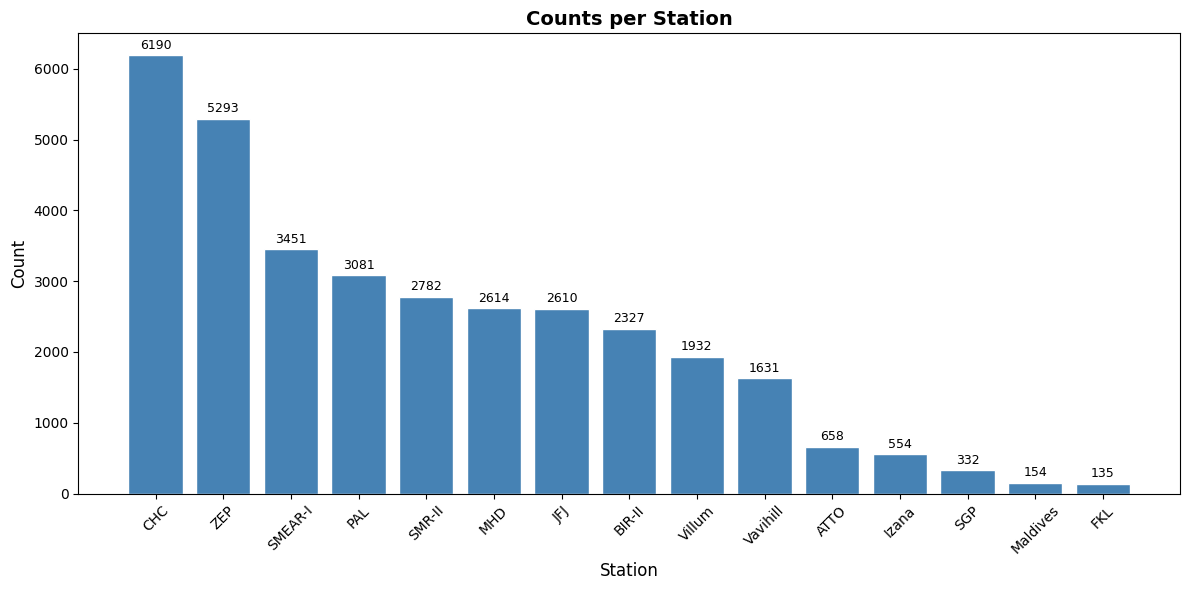

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

# Count occurrences of each station
station_counts = pd.Series(Pairs_acc.station.values).value_counts()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(station_counts.index, station_counts.values, color='steelblue', edgecolor='white')

# Add count labels on top of each bar
for bar, count in zip(bars, station_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(count), ha='center', va='bottom', fontsize=9)

ax.set_title('Counts per Station', fontsize=14, fontweight='bold')
ax.set_xlabel('Station', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 6. Susceptibility regression (module function)

Uses `Function.build_susceptibility_dataset_pooled` from `PeterChurchillFunctions.py`.
The high-Aitken and high-accumulation populations are already pooled across stations,
so this regresses log CDNC on log CCN over the **whole pool at once** (no per-station
loop), within fixed physical updraft bands (`<=0.2 / 0.2-0.5 / >0.5 / Total` m/s).
The slope is the susceptibility S = d ln CDNC / d ln CCN.

In [18]:
# Pooled susceptibility regressor from the shared module (keeps every notebook
# consistent). Operates on the sample-stacked Pairs_* datasets and returns
# (radius, updraft_q) with fixed physical updraft bins:
#     '<=0.2' / '0.2-0.5' / '>0.5' / 'Total'
# For a station-resolved result use build_susceptibility_dataset_by_station instead.


In [72]:
Updraft.where(BigAit.CDNC.notnull(), drop=True).quantile([0,0.75, 0.9,1]).values

array([0.2       , 0.31082115, 0.41328895, 1.51741588])

In [73]:
# High-Aitken population susceptibility (pooled across stations, updraft-stratified)
BigAitReg_ds = Function.build_susceptibility_dataset_pooled(
    Pairs_ait,
    radii,
    bin_dim='radius',
    output_name='BigAitReg',
    updraft_bins= Updraft.where(BigAit.CDNC.notnull(), drop=True).quantile([0,0.75, 0.9,1]).values,
    updraft_labels=('Q0-Q75','Q75-Q90','Q90-Q100','Total')
)


In [75]:
# High-accumulation population susceptibility (pooled across stations, updraft-stratified)
BigAccReg_ds = Function.build_susceptibility_dataset_pooled(
    Pairs_acc,
    radii,
    bin_dim='radius',
    output_name='BigAccReg',
    updraft_bins= Updraft.where(BigAcc.CDNC.notnull(), drop=True).quantile([0,0.75, 0.9,1]).values,
    updraft_labels=('Q0-Q75','Q75-Q90','Q90-Q100','Total')
)


## 7. Susceptibility resolved by vertical level

Same regression but looped per pressure level instead of pooled, to see how
susceptibility varies with height.

In [21]:
import warnings
import numpy as np
import pandas as pd
from scipy import stats

acc_count = pd.Series(Pairs_acc.lev.values).value_counts().sort_index()
all_levels = acc_count.index

# Per-level susceptibility: same equal-count + bin-MEDIAN convention as the
# pooled module regressor, just looped per pressure level instead of pooled.
N_BINS = 100

BigAccReg_lev_ds = xr.Dataset(
    data_vars={
        "slope":     (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "r_value":   (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "std_err":   (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "intercept": (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
    },
    coords={"radius": radii, "lev": all_levels},
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)

    for level in all_levels:
        for r in range(len(radii)):

            # --- Extract and clean (drop non-positive / non-finite before log) ---
            CCN  = Pairs_acc.CCN.sel(lev=level).isel(radius=r).values
            CDNC = Pairs_acc.CDNC.sel(lev=level).values
            valid = (CCN > 0) & (CDNC > 0) & np.isfinite(CCN) & np.isfinite(CDNC)
            lx = np.log10(CCN[valid])
            ly = np.log10(CDNC[valid])

            if lx.size < 10:
                continue

            # --- Equal-COUNT bins: sort by log-CCN, split into N_BINS groups of
            #     equal datapoint count, take each group's MEDIAN ---
            order = np.argsort(lx)
            lx_groups = np.array_split(lx[order], N_BINS)
            ly_groups = np.array_split(ly[order], N_BINS)

            lx_med = np.array([np.median(g) for g in lx_groups if g.size > 0])
            ly_med = np.array([np.median(g) for g in ly_groups if g.size > 0])

            finite = np.isfinite(lx_med) & np.isfinite(ly_med)
            if finite.sum() < 4:
                continue

            # --- Regression through the bin medians ---
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                lx_med[finite], ly_med[finite]
            )

            loc = {"radius": radii[r], "lev": level}
            BigAccReg_lev_ds["slope"].loc[loc]     = slope
            BigAccReg_lev_ds["r_value"].loc[loc]   = r_value
            BigAccReg_lev_ds["std_err"].loc[loc]   = std_err
            BigAccReg_lev_ds["intercept"].loc[loc] = intercept


In [22]:
acc_count = pd.Series(Pairs_acc.lev.values).value_counts().sort_index()
ait_count = pd.Series(Pairs_ait.lev.values).value_counts().sort_index()
all_levels = ait_count.index.union(acc_count.index)


In [23]:
import warnings
import numpy as np
import pandas as pd
from scipy import stats

acc_count = pd.Series(Pairs_acc.lev.values).value_counts().sort_index()
ait_count = pd.Series(Pairs_ait.lev.values).value_counts().sort_index()
all_levels = ait_count.index

# Per-level susceptibility: same equal-count + bin-MEDIAN convention as the
# pooled module regressor, just looped per pressure level instead of pooled.
N_BINS = 100

BigAitReg_lev_ds = xr.Dataset(
    data_vars={
        "slope":     (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "r_value":   (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "std_err":   (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
        "intercept": (["radius", "lev"], np.full((len(radii), len(all_levels)), np.nan)),
    },
    coords={"radius": radii, "lev": all_levels},
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)

    for level in all_levels:
        for r in range(len(radii)):

            # --- Extract and clean (drop non-positive / non-finite before log) ---
            CCN  = Pairs_ait.CCN.sel(lev=level).isel(radius=r).values
            CDNC = Pairs_ait.CDNC.sel(lev=level).values
            valid = (CCN > 0) & (CDNC > 0) & np.isfinite(CCN) & np.isfinite(CDNC)
            lx = np.log10(CCN[valid])
            ly = np.log10(CDNC[valid])

            if lx.size < 10:
                continue

            # --- Equal-COUNT bins: sort by log-CCN, split into N_BINS groups of
            #     equal datapoint count, take each group's MEDIAN ---
            order = np.argsort(lx)
            lx_groups = np.array_split(lx[order], N_BINS)
            ly_groups = np.array_split(ly[order], N_BINS)

            lx_med = np.array([np.median(g) for g in lx_groups if g.size > 0])
            ly_med = np.array([np.median(g) for g in ly_groups if g.size > 0])

            finite = np.isfinite(lx_med) & np.isfinite(ly_med)
            if finite.sum() < 4:
                continue

            # --- Regression through the bin medians ---
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                lx_med[finite], ly_med[finite]
            )

            loc = {"radius": radii[r], "lev": level}
            BigAitReg_lev_ds["slope"].loc[loc]     = slope
            BigAitReg_lev_ds["r_value"].loc[loc]   = r_value
            BigAitReg_lev_ds["std_err"].loc[loc]   = std_err
            BigAitReg_lev_ds["intercept"].loc[loc] = intercept


## 8. Susceptibility maps: diameter × pressure level

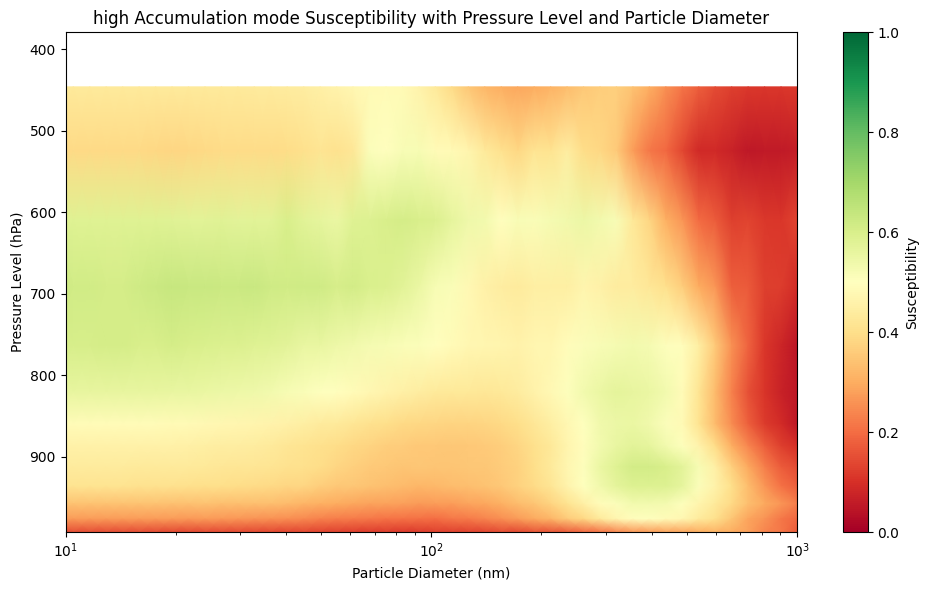

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

mesh = ax.pcolormesh(
    BigAccReg_lev_ds['radius'] * 2,
    BigAccReg_lev_ds['lev'],
    BigAccReg_lev_ds['slope'].T,
    shading='gouraud',
    vmin=0,
    vmax=1,
    cmap='RdYlGn'
)
ax.set_xscale('log')
ax.set_xlim(10,1000)
ax.invert_yaxis()
ax.set_xlabel('Particle Diameter (nm)')
ax.set_ylabel('Pressure Level (hPa)')
ax.set_title('high Accumulation mode Susceptibility with Pressure Level and Particle Diameter')

plt.colorbar(mesh, ax=ax, label='Susceptibility')
plt.tight_layout()
plt.show()

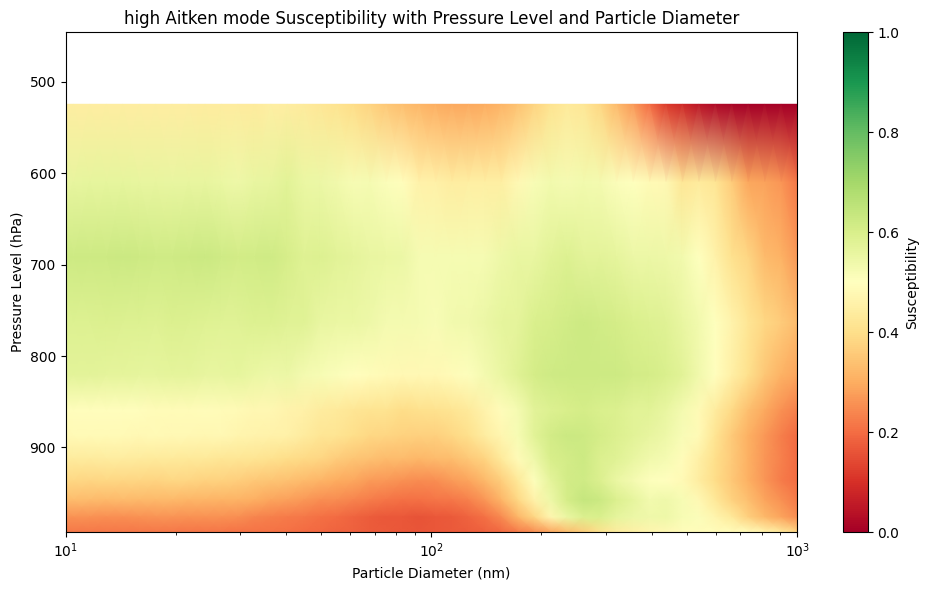

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

mesh = ax.pcolormesh(
    BigAitReg_lev_ds['radius'] * 2,
    BigAitReg_lev_ds['lev'],
    BigAitReg_lev_ds['slope'].T,
    shading='gouraud',
    vmin=0,
    vmax=1,
    cmap='RdYlGn'
)
ax.set_xscale('log')
ax.set_xlim(10,1000)
ax.invert_yaxis()
ax.set_xlabel('Particle Diameter (nm)')
ax.set_ylabel('Pressure Level (hPa)')
ax.set_title('high Aitken mode Susceptibility with Pressure Level and Particle Diameter')

plt.colorbar(mesh, ax=ax, label='Susceptibility')
plt.tight_layout()
plt.show()

## 9. Susceptibility vs particle diameter (updraft-stratified)

Slope (solid) and correlation r (dashed) vs cutoff diameter, one curve per updraft
band, for each mode population.

In [76]:
BigAccReg_ds

<xarray.Dataset> Size: 8kB
Dimensions:    (radius: 61, updraft_q: 4)
Coordinates:
  * radius     (radius) float64 488B 1.0 1.109 1.23 1.365 ... 407.4 451.9 501.2
  * updraft_q  (updraft_q) <U8 128B 'Q0-Q75' 'Q75-Q90' 'Q90-Q100' 'Total'
Data variables:
    slope      (radius, updraft_q) float64 2kB 0.4629 0.4773 ... 0.09853 0.1051
    r_value    (radius, updraft_q) float64 2kB 0.9404 0.9435 ... 0.5083 0.8089
    std_err    (radius, updraft_q) float64 2kB 0.01691 0.01693 ... 0.007718
    intercept  (radius, updraft_q) float64 2kB 0.5391 0.7018 ... 1.991 1.857
Attributes:
    name:     BigAccReg

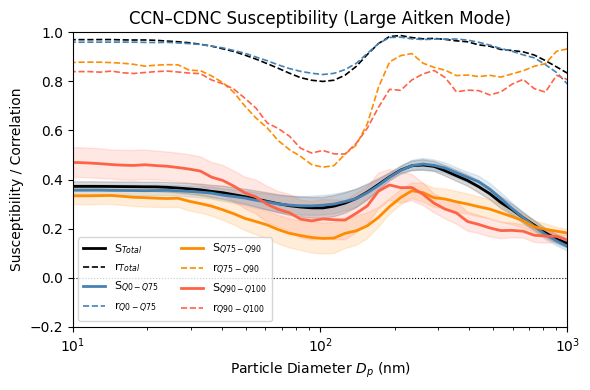

In [77]:
fig, ax = plt.subplots(figsize=(6, 4))

colors = {
    'Total':    'black',
    'Q0-Q75':   'steelblue',
    'Q75-Q90':  'darkorange',
    'Q90-Q100': 'tomato',
}

for q_label, color in colors.items():
    ds = BigAitReg_ds.sel(updraft_q=q_label)
    
    ax.plot(ds['radius']*2, ds['slope'],
            color=color, linewidth=2,
            label=f'S$_{{{q_label}}}$')
    ax.fill_between(ds['radius']*2,
                    ds['slope'] - 1.98*ds['std_err'],
                    ds['slope'] + 1.98*ds['std_err'],
                    color=color, alpha=0.15)
    ax.plot(ds['radius']*2, ds['r_value'],
            '--', color=color, linewidth=1.2,
            label=f'r$_{{{q_label}}}$')

ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax.set_title('CCN–CDNC Susceptibility (Large Aitken Mode)')
ax.set_xlabel('Particle Diameter $D_p$ (nm)')
ax.set_ylabel('Susceptibility / Correlation')
ax.set_ylim([-0.2, 1])
ax.set_xlim([10, 1000])
ax.set_xscale('log')
ax.legend(fontsize=8, ncols=2)
plt.tight_layout()
plt.show()

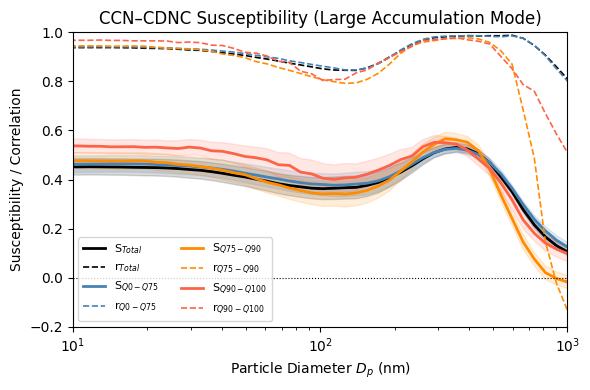

In [78]:
fig, ax = plt.subplots(figsize=(6, 4))

colors = {
    'Total':    'black',
    'Q0-Q75':   'steelblue',
    'Q75-Q90':  'darkorange',
    'Q90-Q100': 'tomato',
}

for q_label, color in colors.items():
    ds = BigAccReg_ds.sel(updraft_q=q_label)
    
    ax.plot(ds['radius']*2, ds['slope'],
            color=color, linewidth=2,
            label=f'S$_{{{q_label}}}$')
    ax.fill_between(ds['radius']*2,
                    ds['slope'] - 1.98*ds['std_err'],
                    ds['slope'] + 1.98*ds['std_err'],
                    color=color, alpha=0.15)
    ax.plot(ds['radius']*2, ds['r_value'],
            '--', color=color, linewidth=1.2,
            label=f'r$_{{{q_label}}}$')

ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax.set_title('CCN–CDNC Susceptibility (Large Accumulation Mode)')
ax.set_xlabel('Particle Diameter $D_p$ (nm)')
ax.set_ylabel('Susceptibility / Correlation')
ax.set_ylim([-0.2, 1])
ax.set_xlim([10, 1000])
ax.set_xscale('log')
ax.legend(fontsize=8, ncols=2)
plt.tight_layout()
plt.show()

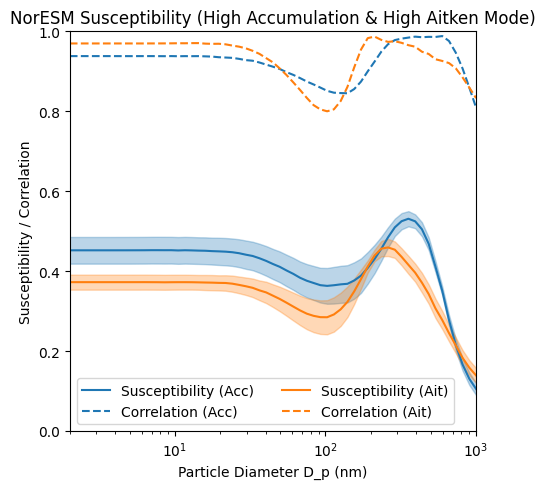

In [79]:
fig, ax = plt.subplots(figsize=[5, 5])

# Accumulation mode
ax.plot(BigAccReg_ds['radius']*2, BigAccReg_ds['slope'].sel(updraft_q = 'Total'), label='Susceptibility (Acc)', color='C0')
ax.fill_between(BigAccReg_ds['radius']*2,
                BigAccReg_ds['slope'].sel(updraft_q = 'Total')-1.98*BigAccReg_ds['std_err'].sel(updraft_q = 'Total'),
                BigAccReg_ds['slope'].sel(updraft_q = 'Total')+1.98*BigAccReg_ds['std_err'].sel(updraft_q = 'Total'),
                alpha=0.3, color='C0')
ax.plot(BigAccReg_ds['radius']*2, BigAccReg_ds['r_value'].sel(updraft_q = 'Total'), '--', color='C0', label='Correlation (Acc)')

# Aitken mode
ax.plot(BigAitReg_ds['radius']*2, BigAitReg_ds['slope'].sel(updraft_q = 'Total'), label='Susceptibility (Ait)', color='C1')
ax.fill_between(BigAitReg_ds['radius']*2,
                BigAitReg_ds['slope'].sel(updraft_q = 'Total')-1.98*BigAitReg_ds['std_err'].sel(updraft_q = 'Total'),
                BigAitReg_ds['slope'].sel(updraft_q = 'Total')+1.98*BigAitReg_ds['std_err'].sel(updraft_q = 'Total'),
                alpha=0.3, color='C1')
ax.plot(BigAitReg_ds['radius']*2, BigAitReg_ds['r_value'].sel(updraft_q = 'Total'), '--', color='C1', label='Correlation (Ait)')

ax.legend(ncols = 2)
ax.set_title('NorESM Susceptibility (High Accumulation & High Aitken Mode)')
ax.set_xlabel('Particle Diameter D_p (nm)')
ax.set_ylabel('Susceptibility / Correlation')
ax.set_ylim([0, 1])
ax.set_xlim([2, 1000])
ax.set_xscale('log')
plt.tight_layout()

## 10. CCN–CDNC scatter diagnostics

Hexbin density / binned-mean / per-quartile regression views of the underlying
log CCN – log CDNC relationship at selected cutoff radii.

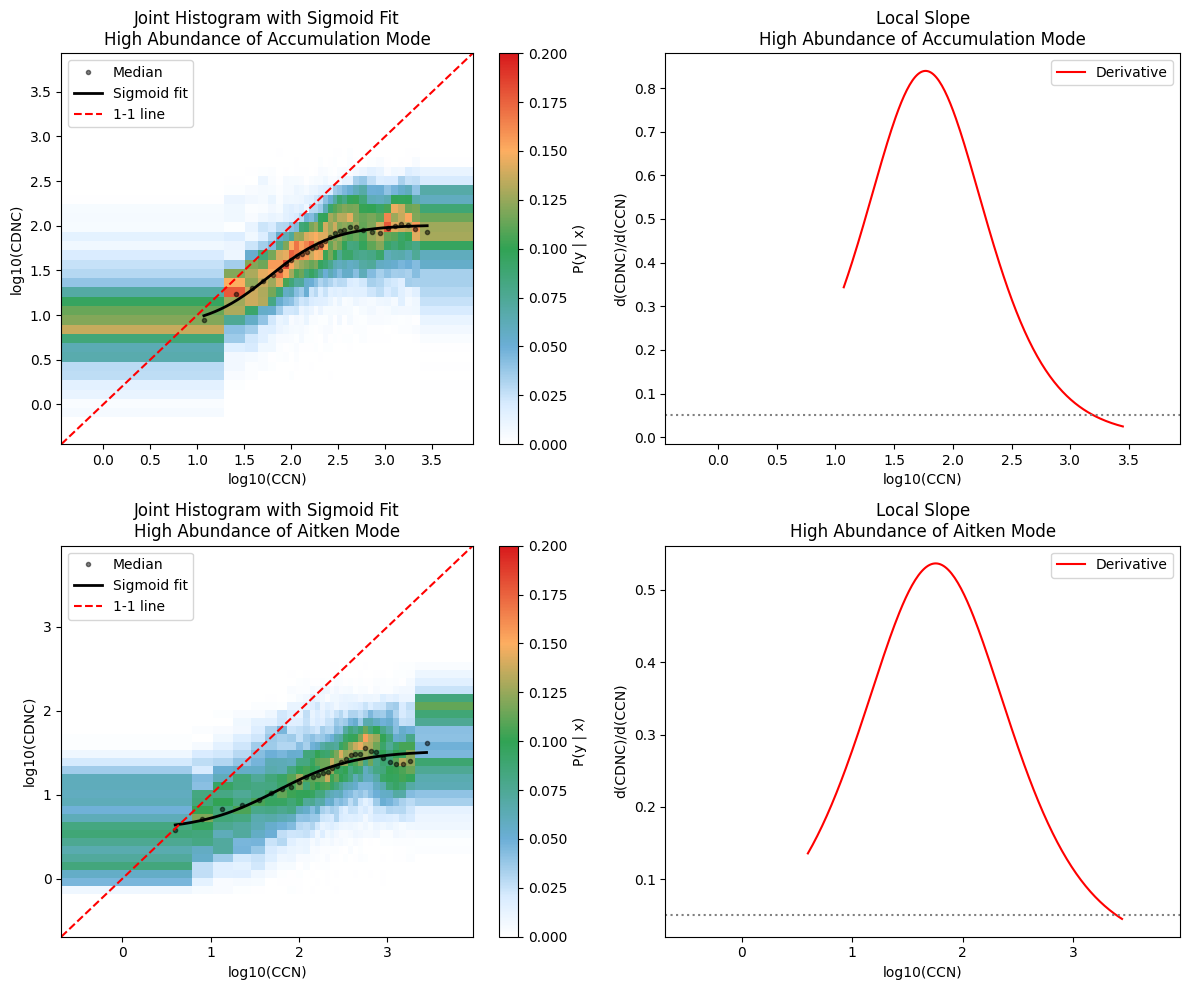

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import curve_fit

# --- Shared colormap (paper style) ---
cmap = LinearSegmentedColormap.from_list(
    "paper_style",
    [
        (0.0,  "#ffffff"),
        (0.1,  "#d9ecff"),
        (0.25, "#6baed6"),
        (0.5,  "#31a354"),
        (0.75, "#fdae61"),
        (1.0,  "#d7191c"),
    ],
)

# --- Sigmoid and its analytic derivative ---
def sigmoid(x, L, x0, k, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def sigmoid_derivative(x, L, x0, k, b):
    exp_term = np.exp(-k * (x - x0))
    return (L * k * exp_term) / (1 + exp_term) ** 2

def prep_population(pairs_ds, radius_idx=30, n_bins=30):
    """Equal-frequency x-binning + per-bin median + sigmoid fit for one population."""
    x = np.log10(pairs_ds["CCN"].isel(radius=radius_idx).values.flatten())
    y = np.log10(pairs_ds["CDNC"].values.flatten())

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    g_min = min(x.min(), y.min())
    g_max = max(x.max(), y.max())

    # Equal-FREQUENCY bins in x (quantile edges); y kept linear
    xbins = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    ybins = np.linspace(y.min(), y.max(), 30)

    H, xedges, yedges = np.histogram2d(x, y, bins=[xbins, ybins])
    H_norm = np.nan_to_num(H / H.sum(axis=1, keepdims=True))   # P(y | x) per x-bin

    # Per-x-bin median of y
    x_centers = 0.5 * (xbins[:-1] + xbins[1:])
    y_median = np.full(n_bins, np.nan)
    x_median = np.full(n_bins, np.nan)

    for i in range(n_bins):
        m = (x >= xbins[i]) & (x < xbins[i + 1])
        if np.any(m):
            y_median[i] = np.median(y[m])
            x_median[i] = np.median(x[m])


    valid = np.isfinite(y_median)
    x_fit, y_fit = x_median[valid], y_median[valid]

    # Sigmoid fit through the bin medians
    p0 = [y_fit.max() - y_fit.min(), np.median(x_fit), 1, y_fit.min()]
    params, _ = curve_fit(sigmoid, x_fit, y_fit, p0=p0, maxfev=10000)

    x_smooth = np.linspace(x_fit.min(), x_fit.max(), 200)
    y_sigmoid = sigmoid(x_smooth, *params)
    y_deriv = sigmoid_derivative(x_smooth, *params)

    return dict(
        xedges=xedges, yedges=yedges, H_norm=H_norm,
        x_fit=x_fit, y_fit=y_fit,
        x_smooth=x_smooth, y_sigmoid=y_sigmoid, y_deriv=y_deriv,
        g_min=g_min, g_max=g_max,
    )

# --- Build both populations ---
populations = [
    ("High Abundance of Accumulation Mode", prep_population(Pairs_acc)),
    ("High Abundance of Aitken Mode",       prep_population(Pairs_ait)),
]

# --- 2x2 layout: rows = Acc / Ait, cols = joint histogram | derivative ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for row, (title, d) in enumerate(populations):
    ax_hist, ax_deriv = axes[row, 0], axes[row, 1]

    # Left: joint histogram + median + sigmoid + 1:1 line
    pcm = ax_hist.pcolormesh(
        d["xedges"], d["yedges"], d["H_norm"].T,
        cmap=cmap, shading="auto", vmin=0, vmax=0.2,
    )
    ax_hist.plot(d["x_fit"], d["y_fit"], "k.", alpha=0.5, label="Median")
    ax_hist.plot(d["x_smooth"], d["y_sigmoid"], "k-", linewidth=2, label="Sigmoid fit")
    ax_hist.plot([d["g_min"], d["g_max"]], [d["g_min"], d["g_max"]],
                 ls="--", c="red", label="1-1 line")
    ax_hist.set_xlim(d["g_min"], d["g_max"])
    ax_hist.set_ylim(d["g_min"], d["g_max"])
    ax_hist.set_xlabel("log10(CCN)")
    ax_hist.set_ylabel("log10(CDNC)")
    ax_hist.set_title(f"Joint Histogram with Sigmoid Fit\n{title}")
    ax_hist.legend()
    fig.colorbar(pcm, ax=ax_hist, label="P(y | x)")

    # Right: sigmoid derivative (local susceptibility) next to its graph
    ax_deriv.plot(d["x_smooth"], d["y_deriv"], "r-", label="Derivative")
    ax_deriv.axhline(0.05, ls=":", c="grey")
    ax_deriv.set_xlim(d["g_min"], d["g_max"])
    ax_deriv.set_xlabel("log10(CCN)")
    ax_deriv.set_ylabel("d(CDNC)/d(CCN)")
    ax_deriv.set_title(f"Local Slope\n{title}")
    ax_deriv.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_1659036/3135803593.py:33: RuntimeWarning: invalid value encountered in divide
  H2_norm = H2 / H2.sum(axis=1, keepdims=True)


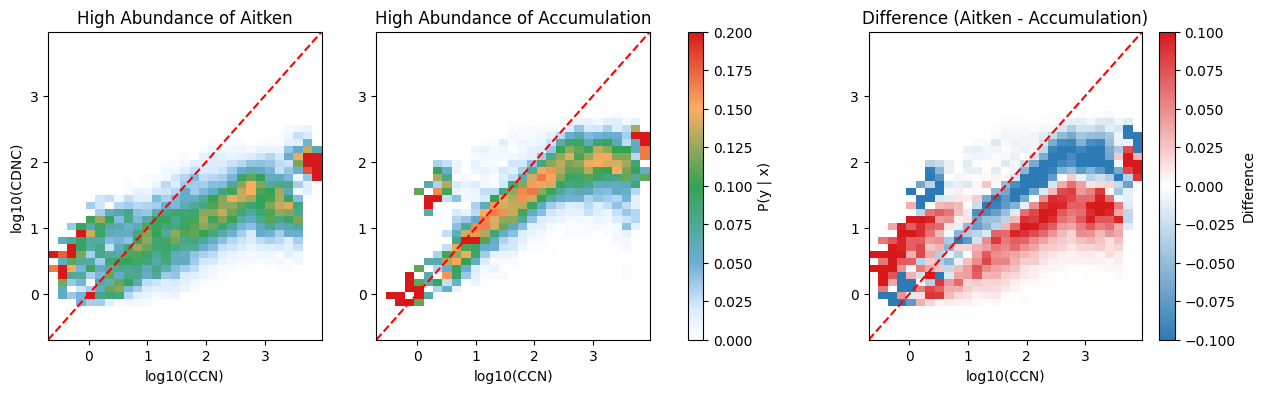

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- Data ---
x1 = np.log10(Pairs_ait['CCN'].isel(radius=30))
y1 = np.log10(Pairs_ait['CDNC'])

x2 = np.log10(Pairs_acc['CCN'].isel(radius=30))
y2 = np.log10(Pairs_acc['CDNC'])

# Flatten & remove NaNs (important!)
x1, y1 = x1.values.flatten(), y1.values.flatten()
x2, y2 = x2.values.flatten(), y2.values.flatten()

mask1 = np.isfinite(x1) & np.isfinite(y1)
mask2 = np.isfinite(x2) & np.isfinite(y2)

x1, y1 = x1[mask1], y1[mask1]
x2, y2 = x2[mask2], y2[mask2]
Graph_min = np.min([np.min(x1),np.min(y1),np.min(x2),np.min(y2)])
Graph_max = np.max([np.max(x1),np.max(y1),np.max(x2),np.max(y2)])
# --- مشترک bin edges (shared!) ---
xbins = np.linspace(min(x1.min(), x2.min()), max(x1.max(), x2.max()), 30)
ybins = np.linspace(min(y1.min(), y2.min()), max(y1.max(), y2.max()), 30)

# --- Histograms ---
H1, xedges, yedges = np.histogram2d(x1, y1, bins=[xbins, ybins])
H2, _, _ = np.histogram2d(x2, y2, bins=[xbins, ybins])

# --- Normalize per x-bin ---
H1_norm = H1 / H1.sum(axis=1, keepdims=True)
H2_norm = H2 / H2.sum(axis=1, keepdims=True)

H1_norm = np.nan_to_num(H1_norm)
H2_norm = np.nan_to_num(H2_norm)

# --- Difference ---
H_diff = H1_norm - H2_norm

# --- Colormaps ---
cmap_main = LinearSegmentedColormap.from_list(
    "paper_style",
    [
        (0.0,  "#ffffff"),
        (0.1,  "#d9ecff"),
        (0.25, "#6baed6"),
        (0.5,  "#31a354"),
        (0.75, "#fdae61"),
        (1.0,  "#d7191c"),
    ]
)

cmap_diff = LinearSegmentedColormap.from_list(
    "diff_map",
    [
        (0.0, "#2c7bb6"),  # blue
        (0.5, "#ffffff"),  # zero
        (1.0, "#d7191c"),  # red
    ]
)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Aitken
pcm1 = axes[0].pcolormesh(
    xedges, yedges, H1_norm.T,
    cmap=cmap_main, shading='auto',
    vmin=0, vmax=0.2
)
axes[0].set_title('High Abundance of Aitken')
axes[0].set_xlabel('log10(CCN)')
axes[0].set_ylabel('log10(CDNC)')
axes[0].set_ylim([Graph_min,Graph_max])
axes[0].set_xlim([Graph_min,Graph_max])
axes[0].plot([Graph_min,Graph_max],[Graph_min,Graph_max], label = '1-1 line', ls = '--', c = 'red')
# Accumulation
pcm2 = axes[1].pcolormesh(
    xedges, yedges, H2_norm.T,
    cmap=cmap_main, shading='auto',
    vmin=0, vmax=0.2
)
axes[1].set_title('High Abundance of Accumulation')
axes[1].set_xlabel('log10(CCN)')
axes[1].set_ylim([Graph_min,Graph_max])
axes[1].set_xlim([Graph_min,Graph_max])
axes[1].plot([Graph_min,Graph_max],[Graph_min,Graph_max], label = '1-1 line', ls = '--', c = 'red')
# Difference
pcm3 = axes[2].pcolormesh(
    xedges, yedges, H_diff.T,
    cmap=cmap_diff, shading='auto',
    vmin=-0.1, vmax=0.1
)
axes[2].set_title('Difference (Aitken - Accumulation)')
axes[2].set_xlabel('log10(CCN)')
axes[2].set_ylim([Graph_min,Graph_max])
axes[2].set_xlim([Graph_min,Graph_max])
axes[2].plot([Graph_min,Graph_max],[Graph_min,Graph_max], label = '1-1 line', ls = '--', c = 'red')
# Colorbars
fig.colorbar(pcm1, ax=axes[:2], label='P(y | x)')
fig.colorbar(pcm3, ax=axes[2], label='Difference')

plt.show()

/tmp/ipykernel_1659036/2085782864.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


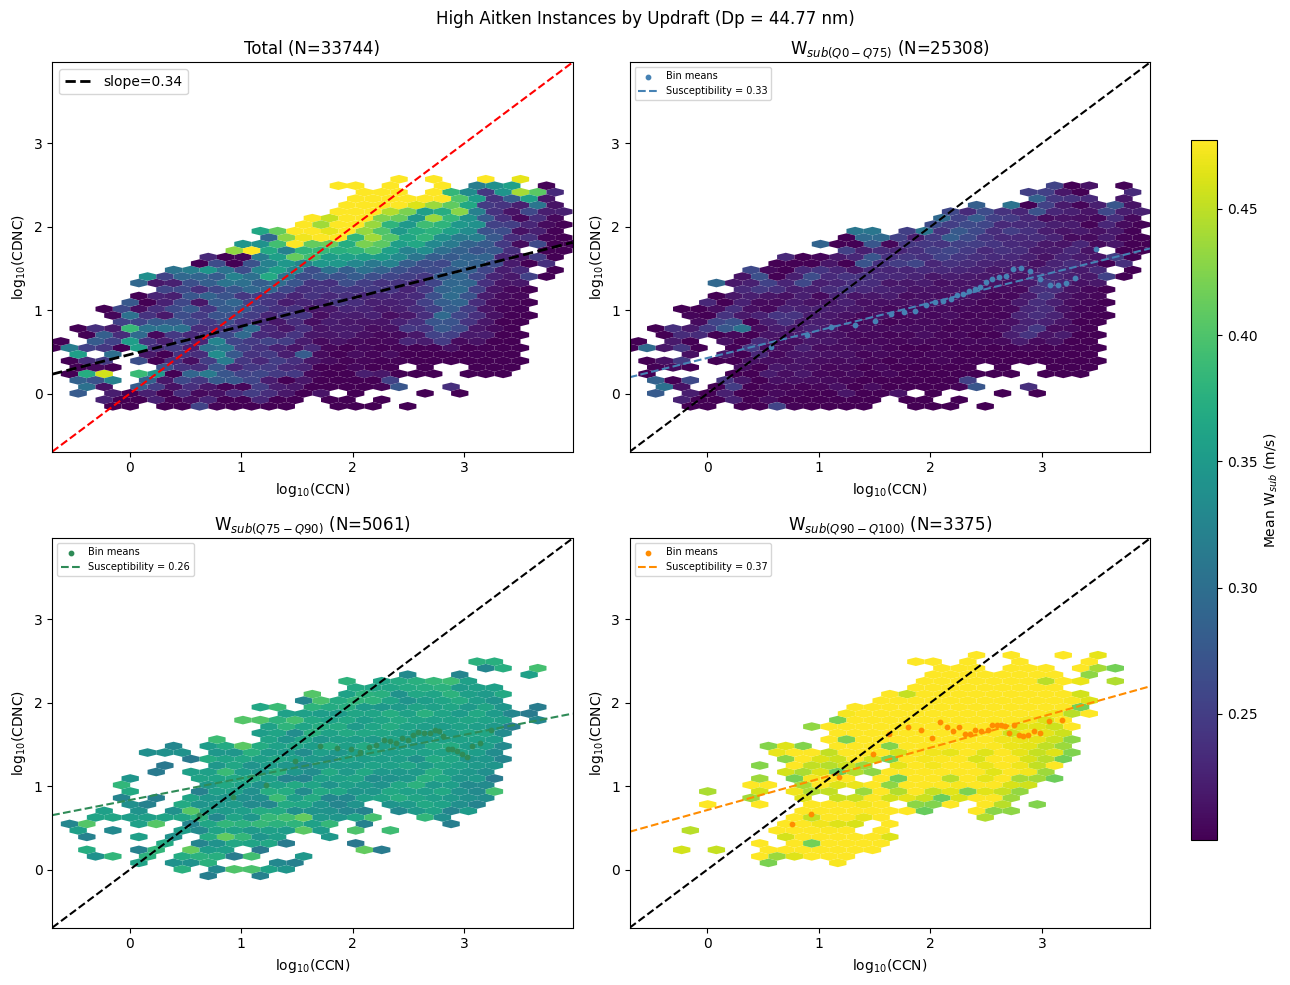

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

r = BigAitReg_ds.slope.sel(updraft_q='Total').argmax().values
r = 30
wsub = Pairs_ait.Updraft
log_x = np.log10(Pairs_ait['CCN'].isel(radius=r))
log_y = np.log10(Pairs_ait['CDNC'])
xmin = log_x.min().values
xmax = log_x.max().values
ymin = log_y.min().values
ymax = log_y.max().values
Graphmin = np.min([xmin, ymin])
Graphmax = np.max([xmax, ymax])
plotline = np.linspace(Graphmin, Graphmax, 20)


# --- Updraft quantile bands (Q0-Q75 / Q75-Q90 / Q90-Q100) ---
q75, q90, q100 = np.nanquantile(wsub.values, [0.75, 0.90, 1.0])
q0 = np.nanmin(wsub.values)
quartile_bins   = [q0, q75, q90, q100]          # quantile edges from wsub
quartile_labels = ['Q0-Q75', 'Q75-Q90', 'Q90-Q100']
colors = ['steelblue', 'seagreen', 'darkorange']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

# --- GLOBAL COLOR SCALE ---
vmin = float(np.nanquantile(wsub, 0.05))
vmax = float(np.nanquantile(wsub, 0.95))

hb_ref = None  # for shared colorbar

# ---------- PANEL 0: TOTAL ----------
ax = axes[0]

valid = np.isfinite(log_x.values) & np.isfinite(log_y.values) & np.isfinite(wsub.values)

lx = log_x.values[valid]
ly = log_y.values[valid]
w  = wsub.values[valid]

n_points = len(lx)

hb = ax.hexbin(
    lx, ly,
    C=w,
    reduce_C_function=np.mean,
    cmap='viridis',
    gridsize=[30, 30],
    vmin=vmin, vmax=vmax,
    mincnt=1,
    edgecolors='none',
    extent=[Graphmin, Graphmax, Graphmin, Graphmax],
)

if hb_ref is None:
    hb_ref = hb

# Total regression
slope = BigAitReg_ds.slope.isel(radius=r).sel(updraft_q='Total').values
intercept = BigAitReg_ds.intercept.isel(radius=r).sel(updraft_q='Total').values

ax.plot(plotline, plotline * slope + intercept,
        color='black', linewidth=2,
        label=f'slope={slope:.2f}', ls='--')

ax.plot([Graphmin, Graphmax], [Graphmin, Graphmax], 'r--')
ax.set_title(f'Total (N={n_points})')
ax.legend()


# ---------- QUANTILE BANDS ----------
for i, (lo, hi, label, color) in enumerate(zip(
        quartile_bins[:-1], quartile_bins[1:], quartile_labels, colors)):

    ax = axes[i + 1]

    mask = ((Pairs_ait.Updraft >= lo) & (Pairs_ait.Updraft <= hi)).values

    lx = log_x.values[mask]
    ly = log_y.values[mask]
    w  = wsub.values[mask]

    valid = np.isfinite(lx) & np.isfinite(ly) & np.isfinite(w)
    lx, ly, w = lx[valid], ly[valid], w[valid]

    n_points = len(lx)

    if n_points < 2:
        continue

    # --- HEXBIN ---
    hb = ax.hexbin(
        lx, ly,
        C=w,
        reduce_C_function=np.mean,
        cmap='viridis',
        gridsize=[30, 30],
        vmin=vmin, vmax=vmax,
        mincnt=1,
        edgecolors='none',
        extent=[Graphmin, Graphmax, Graphmin, Graphmax],
    )

    if hb_ref is None:
        hb_ref = hb

    # --- Equal-COUNT bins: sort by log-CCN, split into N_BINS groups of
    #     equal datapoint count, take each group's mean ---
    N_BINS = 30
    order = np.argsort(lx)
    lx_groups = np.array_split(lx[order], N_BINS)
    ly_groups = np.array_split(ly[order], N_BINS)

    lx_mean = np.array([np.median(g) for g in lx_groups if g.size > 0])
    ly_mean = np.array([np.median(g) for g in ly_groups if g.size > 0])

    valid_bins = np.isfinite(lx_mean) & np.isfinite(ly_mean)
    lx_mean, ly_mean = lx_mean[valid_bins], ly_mean[valid_bins]

    ax.scatter(lx_mean, ly_mean, color=color, s=10, label='Bin means')


    slope_ds = BigAitReg_ds.slope.isel(radius=r).sel(updraft_q=label).values
    intercept_ds = BigAitReg_ds.intercept.isel(radius=r).sel(updraft_q=label).values

    ax.plot(plotline, plotline * slope_ds + intercept_ds,
            color=color, linestyle='--',
            label=f'Susceptibility = {slope_ds:.2f}')

    ax.plot([Graphmin, Graphmax], [Graphmin, Graphmax], 'k--')

    ax.set_title(f'W$_{{sub ({label})}}$ (N={n_points})')
    ax.legend(fontsize=7)


# ---------- FORMAT ----------
for ax in axes:
    ax.set_xlim([Graphmin, Graphmax])
    ax.set_ylim([Graphmin, Graphmax])
    ax.set_xlabel('log$_{10}$(CCN)')
    ax.set_ylabel('log$_{10}$(CDNC)')


# ---------- OUTSIDE COLORBAR ----------
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(hb_ref, cax=cbar_ax, label='Mean W$_{sub}$ (m/s)')

plt.suptitle(f'High Aitken Instances by Updraft (Dp = {radii[r]*2:.2f} nm)')
plt.tight_layout(rect=[0, 0, 0.9, 1])

plt.show()

/tmp/ipykernel_1659036/3401028047.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


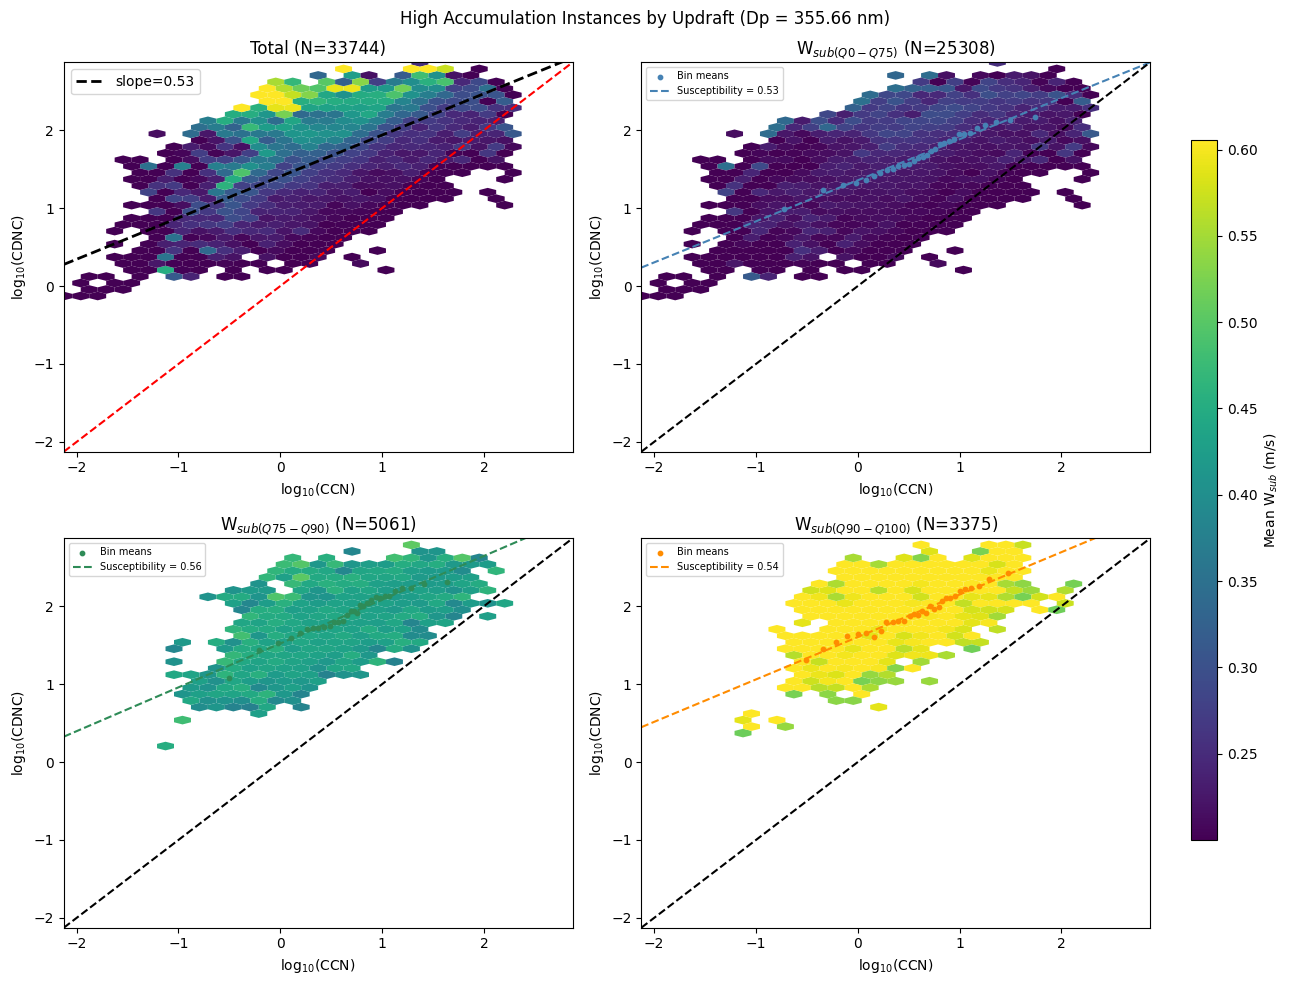

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

r = BigAccReg_ds.slope.sel(updraft_q='Total').argmax().values
wsub = Pairs_acc.Updraft
log_x = np.log10(Pairs_acc['CCN'].isel(radius=r))
log_y = np.log10(Pairs_acc['CDNC'])
xmin = log_x.min().values
xmax = log_x.max().values
ymin = log_y.min().values
ymax = log_y.max().values
Graphmin = np.min([xmin, ymin])
Graphmax = np.max([xmax, ymax])
plotline = np.linspace(Graphmin, Graphmax, 20)


# --- Updraft quantile bands (Q0-Q75 / Q75-Q90 / Q90-Q100) ---
q75, q90, q100 = np.nanquantile(wsub.values, [0.75, 0.90, 1.0])
q0 = np.nanmin(wsub.values)
quartile_bins   = [q0, q75, q90, q100]          # quantile edges from wsub
quartile_labels = ['Q0-Q75', 'Q75-Q90', 'Q90-Q100']
colors = ['steelblue', 'seagreen', 'darkorange']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

# --- GLOBAL COLOR SCALE ---
vmin = float(np.nanquantile(wsub, 0.05))
vmax = float(np.nanquantile(wsub, 0.95))

hb_ref = None  # for shared colorbar

# ---------- PANEL 0: TOTAL ----------
ax = axes[0]

valid = np.isfinite(log_x.values) & np.isfinite(log_y.values) & np.isfinite(wsub.values)

lx = log_x.values[valid]
ly = log_y.values[valid]
w  = wsub.values[valid]

n_points = len(lx)

hb = ax.hexbin(
    lx, ly,
    C=w,
    reduce_C_function=np.mean,
    cmap='viridis',
    gridsize=[30, 30],
    vmin=vmin, vmax=vmax,
    mincnt=1,
    edgecolors='none',
    extent=[Graphmin, Graphmax, Graphmin, Graphmax],
)

if hb_ref is None:
    hb_ref = hb

# Total regression
slope = BigAccReg_ds.slope.isel(radius=r).sel(updraft_q='Total').values
intercept = BigAccReg_ds.intercept.isel(radius=r).sel(updraft_q='Total').values

ax.plot(plotline, plotline * slope + intercept,
        color='black', linewidth=2,
        label=f'slope={slope:.2f}', ls='--')

ax.plot([Graphmin, Graphmax], [Graphmin, Graphmax], 'r--')
ax.set_title(f'Total (N={n_points})')
ax.legend()


# ---------- QUANTILE BANDS ----------
for i, (lo, hi, label, color) in enumerate(zip(
        quartile_bins[:-1], quartile_bins[1:], quartile_labels, colors)):

    ax = axes[i + 1]

    mask = ((Pairs_acc.Updraft >= lo) & (Pairs_acc.Updraft <= hi)).values

    lx = log_x.values[mask]
    ly = log_y.values[mask]
    w  = wsub.values[mask]

    valid = np.isfinite(lx) & np.isfinite(ly) & np.isfinite(w)
    lx, ly, w = lx[valid], ly[valid], w[valid]

    n_points = len(lx)

    if n_points < 2:
        continue

    # --- HEXBIN ---
    hb = ax.hexbin(
        lx, ly,
        C=w,
        reduce_C_function=np.mean,
        cmap='viridis',
        gridsize=[30, 30],
        vmin=vmin, vmax=vmax,
        mincnt=1,
        edgecolors='none',
        extent=[Graphmin, Graphmax, Graphmin, Graphmax],
    )

    if hb_ref is None:
        hb_ref = hb

    # --- Equal-COUNT bins: sort by log-CCN, split into N_BINS groups of
    #     equal datapoint count, take each group's mean ---
    N_BINS = 30
    order = np.argsort(lx)
    lx_groups = np.array_split(lx[order], N_BINS)
    ly_groups = np.array_split(ly[order], N_BINS)

    lx_mean = np.array([np.median(g) for g in lx_groups if g.size > 0])
    ly_mean = np.array([np.median(g) for g in ly_groups if g.size > 0])

    valid_bins = np.isfinite(lx_mean) & np.isfinite(ly_mean)
    lx_mean, ly_mean = lx_mean[valid_bins], ly_mean[valid_bins]

    ax.scatter(lx_mean, ly_mean, color=color, s=10, label='Bin means')


    slope_ds = BigAccReg_ds.slope.isel(radius=r).sel(updraft_q=label).values
    intercept_ds = BigAccReg_ds.intercept.isel(radius=r).sel(updraft_q=label).values

    ax.plot(plotline, plotline * slope_ds + intercept_ds,
            color=color, linestyle='--',
            label=f'Susceptibility = {slope_ds:.2f}')

    ax.plot([Graphmin, Graphmax], [Graphmin, Graphmax], 'k--')

    ax.set_title(f'W$_{{sub ({label})}}$ (N={n_points})')
    ax.legend(fontsize=7)


# ---------- FORMAT ----------
for ax in axes:
    ax.set_xlim([Graphmin, Graphmax])
    ax.set_ylim([Graphmin, Graphmax])
    ax.set_xlabel('log$_{10}$(CCN)')
    ax.set_ylabel('log$_{10}$(CDNC)')


# ---------- OUTSIDE COLORBAR ----------
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(hb_ref, cax=cbar_ax, label='Mean W$_{sub}$ (m/s)')

plt.suptitle(f'High Accumulation Instances by Updraft (Dp = {radii[r]*2:.2f} nm)')
plt.tight_layout(rect=[0, 0, 0.9, 1])

plt.show()

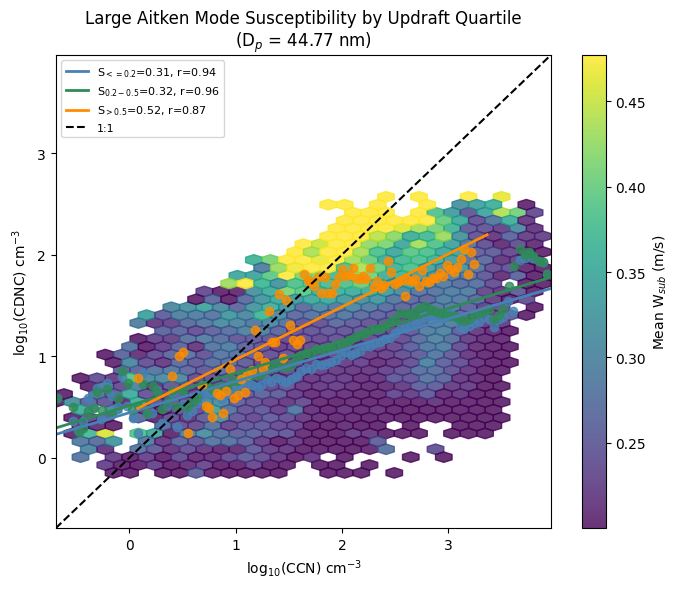

In [47]:
r = 30
wsub = Pairs_ait.Updraft
log_x = np.log10(Pairs_ait['CCN'].isel(radius=r))
log_y = np.log10(Pairs_ait['CDNC'])

# --- Fixed physical updraft bins (match the module's bin scheme) ---
quartile_bins   = [0.0, 0.2, 0.5, np.inf]   # edges for <=0.2 / 0.2-0.5 / >0.5
quartile_labels = ['<=0.2', '0.2-0.5', '>0.5']
colors = ['steelblue', 'seagreen', 'darkorange']

xmin = log_x.min().values
xmax = log_x.max().values
ymin = log_y.min().values
ymax = log_y.max().values
Graphmin = np.min([xmin, ymin])
Graphmax = np.max([xmax, ymax])

fig, ax = plt.subplots(figsize=(7, 6))

# Hexbin background
hb = ax.hexbin(
    log_x, log_y,
    C=wsub,
    reduce_C_function=np.mean,
    cmap='viridis',
    gridsize=[30, 30],
    vmin=float(np.quantile(wsub, 0.05)),
    vmax=float(np.quantile(wsub, 0.95)),
    mincnt=1,
    extent=[Graphmin, Graphmax, Graphmin, Graphmax],
    alpha=0.8,
)
fig.colorbar(hb, ax=ax, label='Mean W$_{sub}$ (m/s)')

# --- Per-quartile regression ---
for i, (lo, hi, label, color) in enumerate(zip(
        quartile_bins[:-1], quartile_bins[1:], quartile_labels, colors)):

    lx = log_x.where((Pairs_ait.Updraft >= lo) & (Pairs_ait.Updraft <= hi)).values
    ly = log_y.where((Pairs_ait.Updraft >= lo) & (Pairs_ait.Updraft <= hi)).values

    # Remove NaNs
    valid = np.isfinite(lx) & np.isfinite(ly)
    lx, ly = lx[valid], ly[valid]

    if len(lx) < 2:
        continue

    # Bin into 100 points using np.digitize
    Log_bins = np.linspace(np.min(lx), np.max(lx), 101)
    bin_idx = np.digitize(lx, Log_bins)

    lx_mean = np.array([lx[bin_idx == b].mean() if np.any(bin_idx == b) else np.nan
                        for b in range(1, 101)])
    ly_mean = np.array([ly[bin_idx == b].mean() if np.any(bin_idx == b) else np.nan
                        for b in range(1, 101)])

    # Drop empty bins (NaN means no data in that bin)
    valid_bins = np.isfinite(lx_mean) & np.isfinite(ly_mean)
    lx_mean, ly_mean = lx_mean[valid_bins], ly_mean[valid_bins]

    if len(lx_mean) < 2:
        continue

    slope, intercept, r_value, p_value, std_err = stats.linregress(lx_mean, ly_mean)
    ax.scatter(lx_mean,ly_mean, color = color, alpha = 0.8)
    ax.plot(Log_bins, Log_bins * slope + intercept,
            color=color, linewidth=2,
            label=f'S$_{{{label}}}$={slope:.2f}, r={r_value:.2f}')

# 1:1 reference
ax.plot([Graphmin, Graphmax], [Graphmin, Graphmax], 'k--', label='1:1')

ax.set_xlim([Graphmin, Graphmax])
ax.set_ylim([Graphmin, Graphmax])
ax.set_xlabel('log$_{10}$(CCN) cm$^{-3}$')
ax.set_ylabel('log$_{10}$(CDNC) cm$^{-3}$')
ax.set_title(f'Large Aitken Mode Susceptibility by Updraft Quartile\n'
             f'(D$_p$ = {radii[r]*2:.2f} nm)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

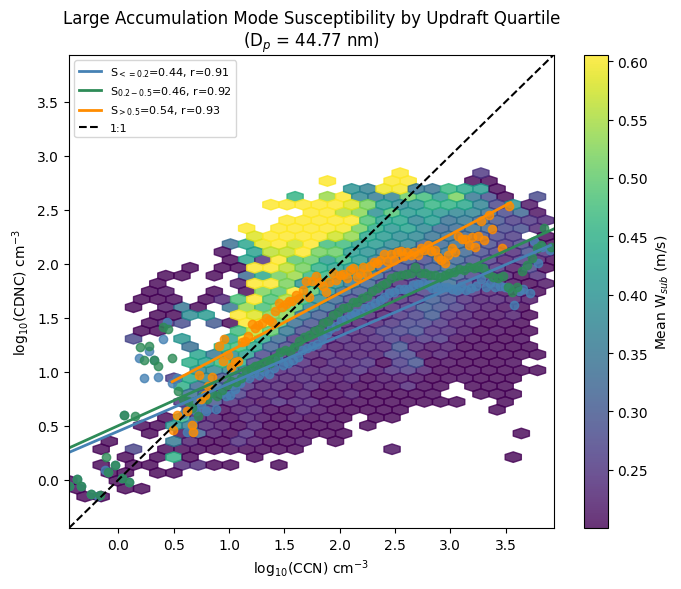

In [48]:
r = 30
wsub = Pairs_acc.Updraft
log_x = np.log10(Pairs_acc['CCN'].isel(radius=r))
log_y = np.log10(Pairs_acc['CDNC'])

# --- Fixed physical updraft bins (match the module's bin scheme) ---
quartile_bins   = [0.0, 0.2, 0.5, np.inf]   # edges for <=0.2 / 0.2-0.5 / >0.5
quartile_labels = ['<=0.2', '0.2-0.5', '>0.5']
colors = ['steelblue', 'seagreen', 'darkorange']

xmin = log_x.min().values
xmax = log_x.max().values
ymin = log_y.min().values
ymax = log_y.max().values
Graphmin = np.min([xmin, ymin])
Graphmax = np.max([xmax, ymax])

fig, ax = plt.subplots(figsize=(7, 6))

# Hexbin background
hb = ax.hexbin(
    log_x, log_y,
    C=wsub,
    reduce_C_function=np.mean,
    cmap='viridis',
    gridsize=[30, 30],
    vmin=float(np.quantile(wsub, 0.05)),
    vmax=float(np.quantile(wsub, 0.95)),
    mincnt=1,
    extent=[Graphmin, Graphmax, Graphmin, Graphmax],
    alpha=0.8,
)
fig.colorbar(hb, ax=ax, label='Mean W$_{sub}$ (m/s)')

# --- Per-quartile regression ---
for i, (lo, hi, label, color) in enumerate(zip(
        quartile_bins[:-1], quartile_bins[1:], quartile_labels, colors)):

    lx = log_x.where((Pairs_acc.Updraft >= lo) & (Pairs_acc.Updraft <= hi)).values
    ly = log_y.where((Pairs_acc.Updraft >= lo) & (Pairs_acc.Updraft <= hi)).values

    # Remove NaNs
    valid = np.isfinite(lx) & np.isfinite(ly)
    lx, ly = lx[valid], ly[valid]

    if len(lx) < 2:
        continue

    # Bin into 100 points using np.digitize
    Log_bins = np.linspace(np.min(lx), np.max(lx), 101)
    bin_idx = np.digitize(lx, Log_bins)

    lx_mean = np.array([lx[bin_idx == b].mean() if np.any(bin_idx == b) else np.nan
                        for b in range(1, 101)])
    ly_mean = np.array([ly[bin_idx == b].mean() if np.any(bin_idx == b) else np.nan
                        for b in range(1, 101)])

    # Drop empty bins (NaN means no data in that bin)
    valid_bins = np.isfinite(lx_mean) & np.isfinite(ly_mean)
    lx_mean, ly_mean = lx_mean[valid_bins], ly_mean[valid_bins]

    if len(lx_mean) < 2:
        continue

    slope, intercept, r_value, p_value, std_err = stats.linregress(lx_mean, ly_mean)
    ax.scatter(lx_mean,ly_mean, color = color, alpha = 0.8)
    ax.plot(Log_bins, Log_bins * slope + intercept,
            color=color, linewidth=2,
            label=f'S$_{{{label}}}$={slope:.2f}, r={r_value:.2f}')

# 1:1 reference
ax.plot([Graphmin, Graphmax], [Graphmin, Graphmax], 'k--', label='1:1')

ax.set_xlim([Graphmin, Graphmax])
ax.set_ylim([Graphmin, Graphmax])
ax.set_xlabel('log$_{10}$(CCN) cm$^{-3}$')
ax.set_ylabel('log$_{10}$(CDNC) cm$^{-3}$')
ax.set_title(f'Large Accumulation Mode Susceptibility by Updraft Quartile\n'
             f'(D$_p$ = {radii[r]*2:.2f} nm)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Updraft CDFs — note the 0.2 m/s floor from `WSUB = max(sqrt(WP2_CLUBB), 0.2)`.

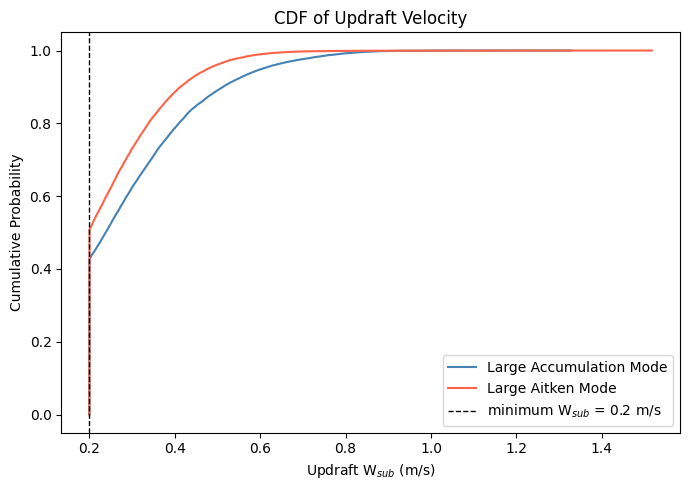

In [49]:
fig, ax = plt.subplots(figsize=(7, 5))

for data, label, color in [
    (Pairs_acc.Updraft.values, 'Large Accumulation Mode', 'steelblue'),
    (Pairs_ait.Updraft.values, 'Large Aitken Mode', 'tomato'),
]:
    vals = data[np.isfinite(data)]
    vals_sorted = np.sort(vals)
    cdf = np.arange(1, len(vals_sorted) + 1) / len(vals_sorted)
    ax.plot(vals_sorted, cdf, label=label, color=color)

ax.axvline(0.2, color='k', linestyle='--', linewidth=1, label='minimum W$_{sub}$ = 0.2 m/s')
ax.set_xlabel('Updraft W$_{sub}$ (m/s)')
ax.set_ylabel('Cumulative Probability')
ax.set_title('CDF of Updraft Velocity')
ax.legend()
plt.tight_layout()
plt.show()

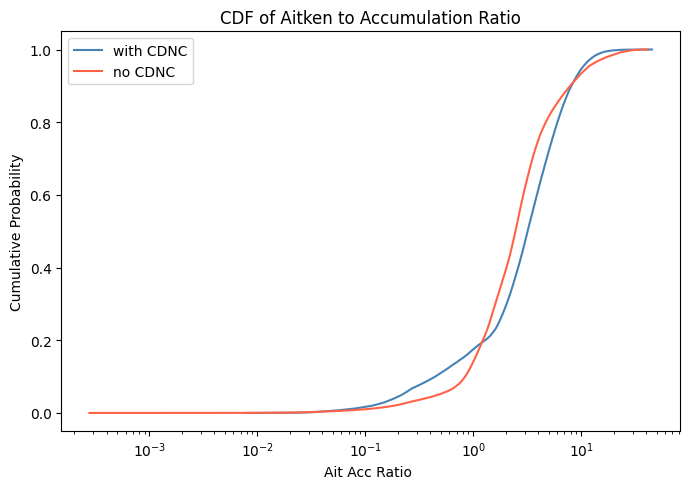

In [50]:
fig, ax = plt.subplots(figsize=(7, 5))

for data, label, color in [
    (AitAccRatio.values, 'with CDNC', 'steelblue'),
    (AitAccRatio2.values, 'no CDNC', 'tomato'),
]:
    vals = data[np.isfinite(data)]
    vals_sorted = np.sort(vals)
    cdf = np.arange(1, len(vals_sorted) + 1) / len(vals_sorted)
    ax.plot(vals_sorted, cdf, label=label, color=color)
ax.set_xscale('log')
ax.set_xlabel('Ait Acc Ratio ')
ax.set_ylabel('Cumulative Probability')
ax.set_title('CDF of Aitken to Accumulation Ratio')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Mode occurrence by pressure level

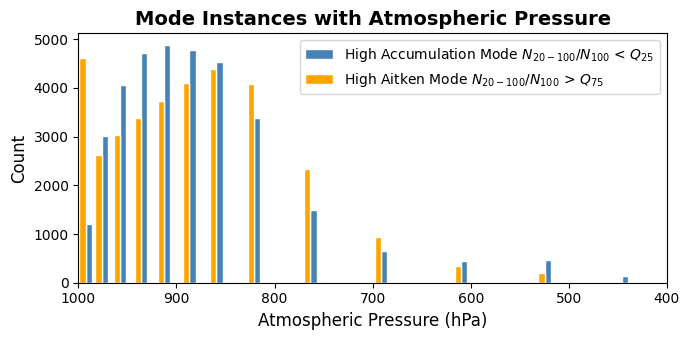

In [59]:


# Count occurrences


# Align both series to the same index
acc_count = acc_count.reindex(all_levels, fill_value=0)
ait_count = ait_count.reindex(all_levels, fill_value=0)

# Width based on minimum spacing between pressure levels
min_spacing = np.diff(np.sort(all_levels)).min()
width = min_spacing * 0.4

fig, ax = plt.subplots(figsize=(7, 3.5))
bars1 = ax.bar(all_levels - width/2, acc_count.values, width=width,
               color='steelblue', edgecolor='white', label='High Accumulation Mode $N_{20-100}/N_{100}$ < $Q_{25}$')
bars2 = ax.bar(all_levels + width/2, ait_count.values, width=width,
               color='orange', edgecolor='white', label='High Aitken Mode $N_{20-100}/N_{100}$ > $Q_{75}$')
ax.set_xlim([1000,400])
ax.set_xlabel('Atmospheric Pressure (hPa)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Mode Instances with Atmospheric Pressure', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Per-level susceptibility curves

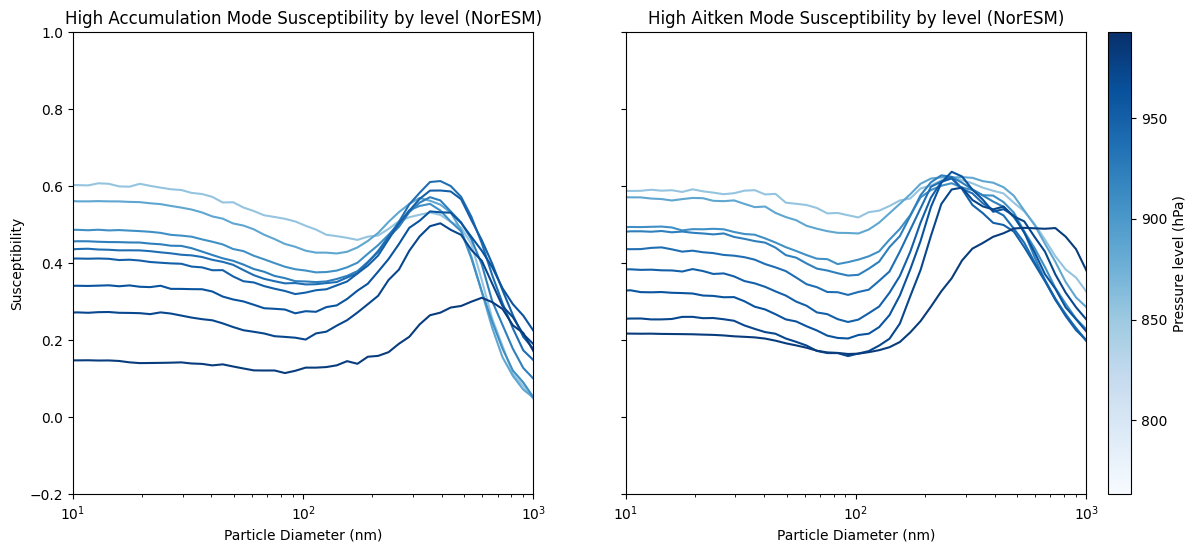

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# --- Per-level sample counts; keep only levels with > 1000 points ---
acc_count = pd.Series(Pairs_acc.lev.values).value_counts()
ait_count = pd.Series(Pairs_ait.lev.values).value_counts()

acc_levels = [l for l in BigAccReg_lev_ds.lev.values if acc_count.get(l, 0) > 1000]
ait_levels = [l for l in BigAitReg_lev_ds.lev.values if ait_count.get(l, 0) > 1000]

# --- Shared color scale across BOTH panels (map pressure level -> color) ---
all_levels = np.array(acc_levels + ait_levels, dtype=float)
norm = Normalize(vmin=all_levels.min(), vmax=all_levels.max())
cmap = cm.Blues

def level_color(lev_val):
    # rescale into 0.4-0.95 so no near-white lines, but keep a shared mapping
    return cmap(0.4 + 0.55 * norm(lev_val))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

panels = [
    (axes[0], BigAccReg_lev_ds, acc_levels, 'High Accumulation Mode Susceptibility by level (NorESM)'),
    (axes[1], BigAitReg_lev_ds, ait_levels, 'High Aitken Mode Susceptibility by level (NorESM)'),
]

for ax, ds, levels, title in panels:
    for lev_val in levels:
        ax.plot(
            ds.radius * 2,
            ds.slope.sel(lev=lev_val),
            color=level_color(lev_val),
            label=f'{lev_val:.2f} hPa',
        )
    ax.set_xscale('log')
    ax.set_xlabel('Particle Diameter (nm)')
    ax.set_title(title)
    ax.set_xlim([10, 1000])
    ax.set_ylim([-0.2, 1])

axes[0].set_ylabel('Susceptibility')

# --- Single shared colorbar (continuous pressure scale) ---
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.046, pad=0.02)
cbar.set_label('Pressure level (hPa)')

plt.show()